## 6DoF Powered Descent Guidance SCP

Imports

In [ ]:
# Basic imports
import importlib
import numpy                as np
import matplotlib.pyplot    as plt
import pandas               as pd
import copy

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp              as scp
import trajopt.core.Trajopt                         as prob
import trajopt.core.modules.utils.config_loader                  as cfg
import trajopt.core.modules.utils.tools                          as tools
import trajopt.analysis.default_analysis            as default_analysis
import trajopt.analysis.statistics                  as stats
import trajopt.core.modules.analysis.monte_carlo    as mc
import trajopt.core.modules.analysis.standalone     as standalone

from trajopt.analysis.trajplots import *

from trajopt.analysis.plots_for_scitech26_pdg import *

np.random.seed(0)  # for reproducibility



setup problem and run SCP

In [ ]:
example_name = "lander_6dof"
nominal_config  = cfg.load_configs(example_name)

# either generate mc variations from yamls or load existing saved mc variations
gen_mc_variations    = 1

# save mc variations to file (specificy a name for this set of mc variations as well)
save_mc_variations   = 0
mc_name = "mc1"

# save scenario data to file (save the scenario data struct)
save_scenario_data   = 0

# run mc analysis loop
# TODO(Carlos and  Dan):  shouldn't need to return trajopt_obj, just scenario data, something below depends on it though (this is the most recent trajopt_obj instance)
scenario_data, trajopt_obj = mc.run_mc_analysis(example_name, nominal_config, gen_mc_variations, save_mc_variations, save_scenario_data, mc_name)


scales: 
d: 1.0000, t: 1.0000, m: 1.0000, v: 1.0000, a: 1.0000, f: 1.0000, ang: 57.2958, angv: 57.2958, none: 1.0000
Cost initial: 0.0
total number of parameters: 3638
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: lander: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
--------------------------------------------------------------------------------------------------------------------------------------

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    01622.1   |   0002.9  |   0172.5   |   -1.2    |      -12.0      |    -12.0    |     +00.3   |    optimal    |   4.50   |   0.0
     02     |    00003.6   |   0003.3  |   0158.9   |   +0.5    |      -12.0      |    -12.0    |     -00.3   |    optimal    |   4.11   |   0.0
     03     |    00002.7   |   0003.4  |   0234.7   |   +0.1    |      -12.0      |    -12.0    |     -02.1   |    optimal    |   4.39   |   0.0
     04     |    00004.1   |   0003.4  |   0151.4   |   -0.1    |      -12.0      |    -12.0    |     -02.8   |    optimal    |   4.55   |   0.0
     05     |    00003.5   |   0003.3  |   0156.5   |   -0.6    |      -12.0      |    -12.0    |     -03.4   |    optimal    |   4.94   |   0.0
     06     |    00002.9   |   0003.3  |   0155.1   |   -0.9    |      -12.0      |    -12.0    |     -03.7   |    optimal    |   5.06   |   0.0
     07     |    00002.5   |   0003.2  |   0226.1   |   -1.6    |      -12.0      |    -12.0    |     -04.0   |    optimal    |   

mc analysis

In [3]:
# # file = '~/masters-link/ACL/prototypes/trajopt/src/trajopt/examples/vtol1_entry_3dof/data/statistics/mc1.txt' # Example file
# # analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

# # Can run without filename if you don't want to save LaTeX tables
# analysis = stats.analyze_quality_metrics(scenario_data)

In [4]:
data = {'scenario1':scenario_data}
PLTS1 = SCVXPLOTS(data);
cases = {'scenarios':['scenario1'],'methods':['standard','autotune'],'runs':list(range(1000)),'iters':list(range(1000))[1:]}
preProcess(PLTS1,trajopt_obj,cases=cases);

/Users/carlosm/Documents/guidance/hypersonics/trajopt/src/trajopt/analysis/custom_functions_dan_pdg.py:52: RuntimeWarning: invalid value encountered in arccos
  return (180/np.pi)*np.arccos(1 - 2*(z[9]**2 + z[10]**2))


In [5]:

versions = ['methodvar'];
figpaths = ['figs/methodvar/'];

displayfigs = True;
printfigs = True; 
transparentfigs = True; 

specs = {}

specs['standalone'] = {'methods':['autotune'],'runs':[0],'itrs':[]};
specs['sa_iters'] = {'methods':['autotune'],'runs':[0],'itrs':list(range(1000))[1:]};
specs['methodvar'] = {'methods':['standard','autotune'],'runs':[0]}; #,'itrs':list(range(1000))[1:]};
specs['mvmc'] = {'methods':['standard','autotune'],'runs':list(range(10))}; #,'itrs':list(range(1000))[1:]};
specs['montecarlo'] = {'methods':['standard'],'runs':list(range(1000))}; #'itrs':list(range(1000))[1:]};

######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 

## default pens are set in the function plots_for_scitech26.py
## set new pens here. 
PENS = {};  
PENS['newpen'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};

plotparams = {};
plotparams['trajopt_obj'] = trajopt_obj
plotparams['data'] = data;
plotparams['versions'] = versions;
plotparams['specs'] = specs;
plotparams['PENS'] = PENS;
plotparams['figpaths'] = figpaths;
plotparams['transparentfigs'] = transparentfigs;
plotparams['printfigs'] = printfigs;
plotparams['displayfigs'] = displayfigs;

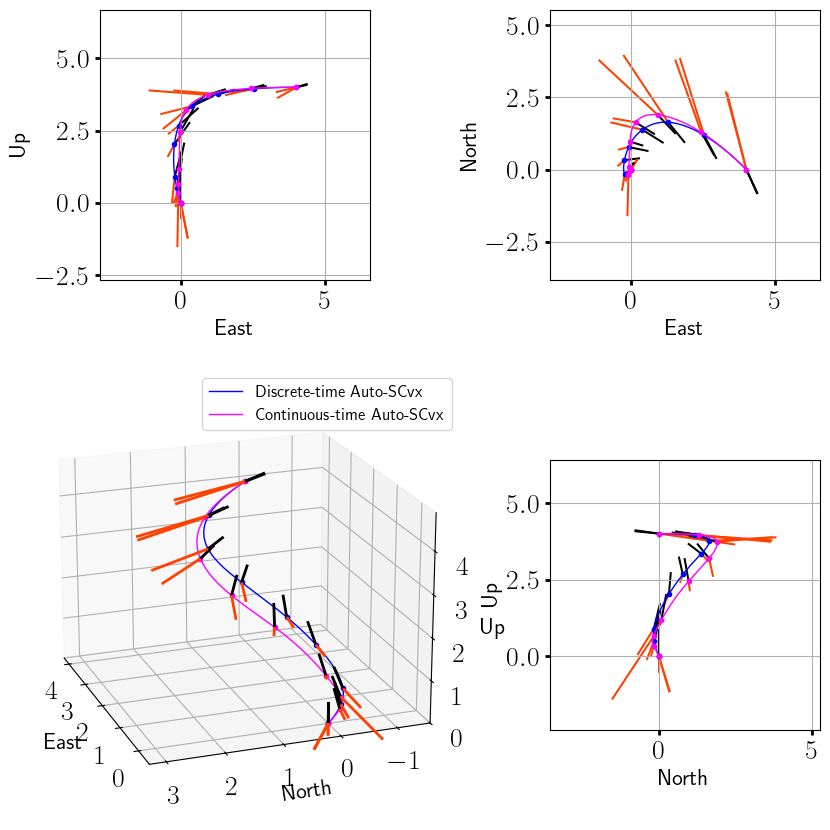

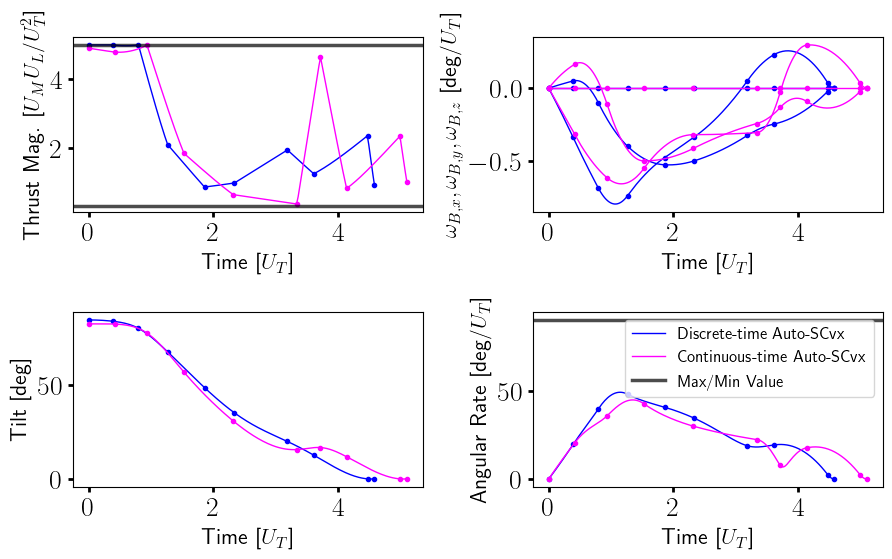

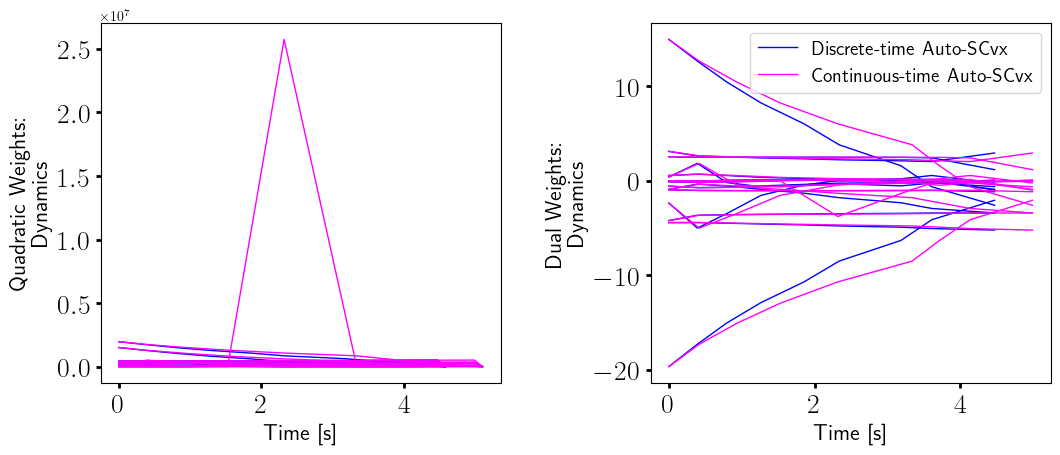

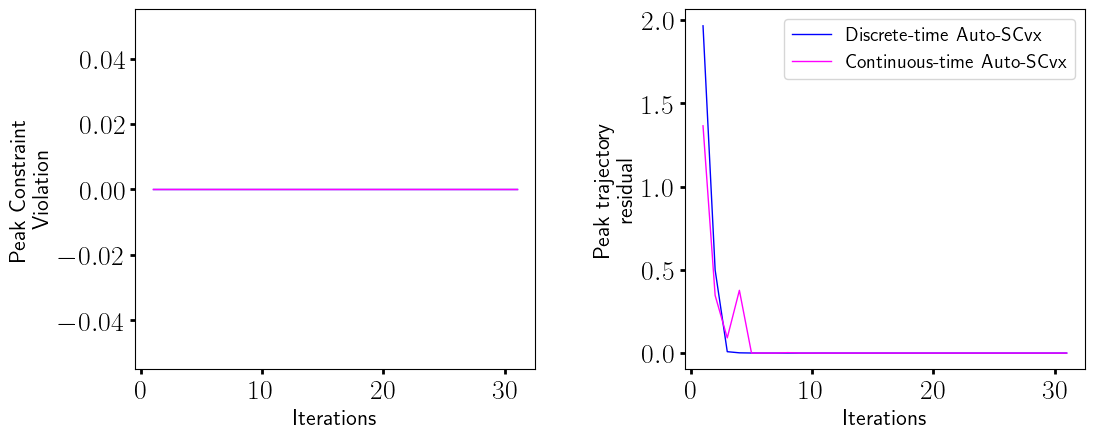

In [6]:
%load_ext autoreload
%autoreload 2

ALL_PLOTS = True
if ALL_PLOTS:

    newparams = {'usequiver':True,'sideviews':True,'skip':1}
    makePlotTrajs(PLTS1,ins={**plotparams,**newparams});
    
    makePlotStates(PLTS1,ins=plotparams);
    
    # ### looks in 'weights' plots over time 
    newparams = {'weights_info':['W_dyn','dual_dyn']}
    # # # newparams = {'weights_info':[('W_dyn',(0)),('dual_dyn',(0,1))]}
    makePlotWghtsFlex(PLTS1,ins={**plotparams,**newparams});
    
    ### looks in 'conv_data' plots over iterations
    # newparams = {'converge_info':['chk_feas_term','chk_feas_dyn']}
    makePlotConvsFlex(PLTS1,ins={**plotparams,**newparams});


In [7]:
# Direction Cosine Matrix Function
def DCM(q): 
    return np.array(
        [
            [
                1 - 2 * (q[2] ** 2 + q[3] ** 2),
                2 * (q[1] * q[2] + q[0] * q[3]),
                2 * (q[1] * q[3] - q[0] * q[2]),
            ],
            [
                2 * (q[1] * q[2] - q[0] * q[3]),
                1 - 2 * (q[1] ** 2 + q[3] ** 2),
                2 * (q[2] * q[3] + q[0] * q[1]),
            ],
            [
                2 * (q[1] * q[3] + q[0] * q[2]),
                2 * (q[2] * q[3] - q[0] * q[1]),
                1 - 2 * (q[1] ** 2 + q[2] ** 2),
            ],
        ]
    )

import matplotlib.pyplot as plt
# %matplotlib ipympl
matplotlib.rcParams['axes3d.mouserotationstyle'] = 'azel'

soln1 = scenario_data['standard']['mc_data'][0]['iters'][-1]
soln2 = scenario_data['autotune']['mc_data'][0]['iters'][-1]

t_opt1 = soln1['t_opt']
z_opt1 = soln1['z_opt']
nu_opt1 = soln1['nu_opt']

t_nl1 = soln1['t_nl']
z_nl1 = soln1['z_nl']
nu_nl1 = soln1['nu_nl']

t_opt2 = soln2['t_opt']
z_opt2 = soln2['z_opt']
nu_opt2 = soln2['nu_opt']

t_nl2 = soln2['t_nl']
z_nl2 = soln2['z_nl']
nu_nl2 = soln2['nu_nl']

print(nu_nl2[-1])

DCMs = np.empty((trajopt_obj.method.N, 3, 3))
u_vecs = np.empty_like(nu_opt1[:, :trajopt_obj.model.m])
rt_I = np.zeros((trajopt_obj.method.N, 3))
body_vecs = np.zeros((trajopt_obj.method.N, 3))

veh = trajopt_obj.mission.vehicle
rt = np.array([veh["rt1"], veh["rt2"], veh["rt3"]])

for i in range(trajopt_obj.method.N):
    DCMs[i] = DCM(z_opt1[i, 7:11])

    u_vecs[i] = 0.3* DCMs[i].T @ nu_opt1[i, :trajopt_obj.model.m]
    rt_I[i] = DCMs[i].T @ rt
    body_vecs[i] = 0.5 * DCMs[i].T @ np.array([1, 0, 0])

[ 1.00051562e+00 -1.98206674e-15 -2.68730644e-15]


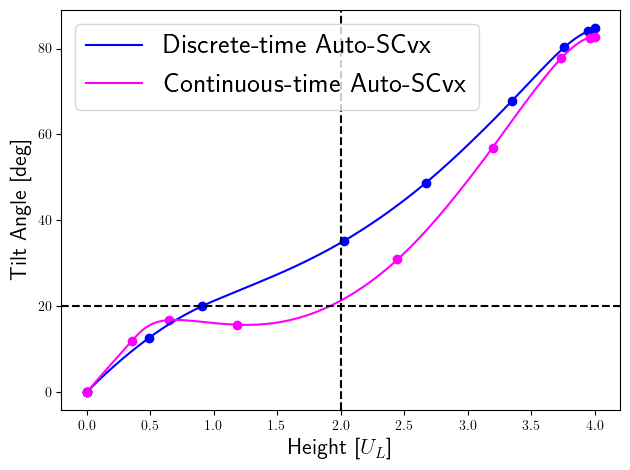

In [8]:


PENS = {};
PENS['CT'] = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
PENS['NONCT'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};

tilt_angles_nl1 = np.zeros(20 * trajopt_obj.method.N)
for i in range(20 * trajopt_obj.method.N):
    tilt_angles_nl1[i] = np.rad2deg(np.arccos(1 - 2 * np.sum(z_nl1[i, 9:11] ** 2)))

tilt_angles_opt1 = np.zeros(trajopt_obj.method.N)
for i in range(trajopt_obj.method.N):
    tilt_angles_opt1[i] = np.rad2deg(np.arccos(1 - 2 * np.sum(z_opt1[i, 9:11] ** 2)))


tilt_angles_nl2 = np.zeros(20 * trajopt_obj.method.N)
for i in range(20 * trajopt_obj.method.N):
    tilt_angles_nl2[i] = np.rad2deg(np.arccos(1 - 2 * np.sum(z_nl2[i, 9:11] ** 2)))

tilt_angles_opt2 = np.zeros(trajopt_obj.method.N)
for i in range(trajopt_obj.method.N):
    tilt_angles_opt2[i] = np.rad2deg(np.arccos(1 - 2 * np.sum(z_opt2[i, 9:11] ** 2)))


penn = PENS['NONCT']
lrgba = penn['lrgba']; msz = penn['msz']; msty = penn['msty']; lw = penn['lw']; ls = penn['ls'];
h1 = plt.plot(z_nl1[:, 1], tilt_angles_nl1,linestyle=ls,color=lrgba,label='blarg1')[0]
h2 = plt.scatter(z_opt1[:, 1], tilt_angles_opt1,color=lrgba,label='blarg2')

penn = PENS['CT']
lrgba = penn['lrgba']; msz = penn['msz']; msty = penn['msty']; lw = penn['lw']; ls = penn['ls'];
h3 = plt.plot(z_nl2[:, 1], tilt_angles_nl2,linestyle=ls,color=lrgba,label='blarg3')[0]
h4 = plt.scatter(z_opt2[:, 1], tilt_angles_opt2,color=lrgba,label='blarg4')


plt.axvline(x=2.0, linestyle='--', color='black')
plt.axhline(y=20.0, linestyle='--', color='black')

labels = ['Discrete-time Auto-SCvx', 'Continuous-time Auto-SCvx']
handles = [h1,h3]
plt.legend(handles,labels,fontsize=20)


# plt.title("Tilt angle vs height")
plt.xlabel("Height [$U_{L}$]", fontsize=16)
plt.ylabel("Tilt Angle [deg]",fontsize=16)
plt.tight_layout()
plt.savefig('figs/stc.pdf',bbox_inches='tight',pad_inches=0,transparent=True)
plt.show()